# Retention Analysis — Dacon E-Commerce Dataset

## 분석 개요

고객의 **첫 구매 월(코호트)** 을 기준으로, 이후 월별 재구매율(Retention)을 분석한다.

| 섹션 | 내용 |
|------|------|
| 1 | 데이터 로드 및 코호트 구성 |
| 2 | 월별 신규 고객 수 |
| 3 | 코호트 리텐션 분석 (히트맵 · 코호트별 추이 · 평균 추이) |
| 4 | 마케팅 비용과 재구매율 |
| 5 | 카테고리별 리텐션 분석 |

> **Retention 정의**: 코호트 월에 구매한 고객 중, 이후 +N개월에도 구매한 고객의 비율  
> **데이터 한계**: 2019년 1년치 데이터만 존재하므로, 첫 구매월은 데이터 내 최초 구매월 기준으로 처리  
> → 초기 코호트(1-2월)일수록 추적 가능한 기간이 길어 더 신뢰도 높은 리텐션 측정 가능

---
## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

---
## 1. 데이터 로드 및 코호트 구성

In [2]:
# 고객별 월별 구매 이력 — 전체 첫 구매월(first_month)과 경과월(month_diff) 포함
df = pd.read_sql(
    """
    WITH first_purchases AS (
        SELECT
            고객ID,
            MIN(월) AS first_month
        FROM orders_master
        GROUP BY 고객ID
    )
    
    SELECT
        o.고객ID,
        o.월,
        f.first_month,
        o.월 - f.first_month AS month_diff
    FROM orders_master o
    LEFT JOIN first_purchases f ON o.고객ID = f.고객ID
    """,
    engine
)

df.head()

,고객ID,월,first_month,month_diff
0,USER_1358,1,1,0
1,USER_1358,1,1,0
2,USER_1358,1,1,0
3,USER_1358,1,1,0
4,USER_1358,1,1,0


In [3]:
# 고객-월 단위 중복 제거 (같은 달에 여러 거래 → 1건으로)
df = df.drop_duplicates(subset=['고객ID', '월'])

print(f"고유 고객 수: {df['고객ID'].nunique():,}명")
print(f"데이터 행 수: {len(df):,}건")

고유 고객 수: 1,468명
데이터 행 수: 2,577건


>전체 고객(1,468명)이 구매한 월의 수는 총 2,577개, **1인당 평균 1.76개월(12개월 중)** 에만 구매가 발생한 셈이다.  
대부분의 고객이 한 달 내지 두 달만 구매하고 장기적으로 재방문하지 않는 패턴임을 시사한다.

---
## 2. 월별 신규 고객 수

In [4]:
# 월별 코호트 크기 — 해당 월에 첫 구매한 신규 고객 수
cohort_size = pd.read_sql(
    """
    SELECT 
        first_month AS 월, 
        COUNT(DISTINCT 고객ID) AS cohort_size
    FROM (
        SELECT 
            고객ID, 
            MIN(월) AS first_month
        FROM orders_master
        GROUP BY 고객ID
    ) base
    GROUP BY first_month
    ORDER BY first_month
    """,
    engine
)
cohort_size

,월,cohort_size
0,1,215
1,2,96
2,3,177
3,4,163
4,5,112
5,6,137
6,7,93
7,8,136
8,9,78
9,10,87


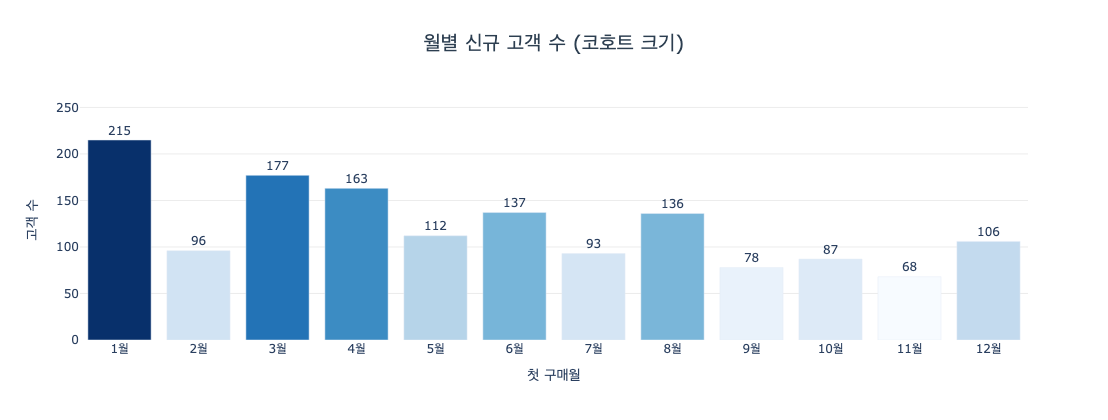

In [5]:
fig = go.Figure(go.Bar(
    x=[f'{m}월' for m in cohort_size['월']],
    y=cohort_size['cohort_size'],
    text=cohort_size['cohort_size'],
    textposition='outside',
    marker=dict(
        color=cohort_size['cohort_size'],
        colorscale='Blues',
        showscale=False
    )
))

fig.update_layout(
    title=dict(text='월별 신규 고객 수 (코호트 크기)', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='첫 구매월',
    yaxis_title='고객 수',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec',
               range=[0, cohort_size['cohort_size'].max() * 1.2]),
    height=420
)
fig.show()

### 인사이트

- 1월 신규 유입이 215명으로 연중 최다 — 연초 프로모션·신년 구매 수요가 집중된 것으로 보임
- 전반기(1-6월) 월평균 150명 vs 후반기(7-12월) 월평균 95명 — 하반기 신규 유입이 약 37% 감소
- 7·9·11월이 각각 93·78·68명으로 최저 구간 형성, 12월은 106명으로 소폭 반등
- 코호트 분석 시 초기 코호트(1-3월)는 표본이 크고 관측 기간이 길어 리텐션 신뢰도가 높으나, 후기 코호트는 표본 및 관측 기간 모두 짧아 해석에 주의가 필요함

---
## 3. 코호트 리텐션 분석

코호트 월 기준 신규 고객 수(+0개월) 대비, 이후 +N개월에 재구매한 고객 비율을 히트맵·코호트별 추이·전체 평균 추이로 확인한다.

In [6]:
# 전체 코호트 집계
cohort_data = (
    df.groupby(["first_month", "month_diff"])["고객ID"]
    .nunique()
    .reset_index(name="customers")
)
cohort_pivot = cohort_data.pivot(index="first_month", columns="month_diff", values="customers")
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3) * 100

# ── 코호트 집계 ──
def build_cohort(df_sub):
    pivot = (
        df_sub.groupby(["first_month","month_diff"])["고객ID"]
        .nunique()
        .reset_index(name="customers")
        .pipe(lambda d: d.pivot(index="first_month", columns="month_diff", values="customers"))
    )
    pct = pivot.divide(pivot[0], axis=0).round(3) * 100
    return pivot, pct

# ── 코호트 히트맵 시각화 ──
def draw_cohort_heatmap(pivot, pct, title):
    hmap = pct.drop(columns=[0], errors="ignore")
    y_labels = [f"{i}월 코호트" for i in hmap.index]
    x_labels = [f"+{c}개월" for c in hmap.columns]
    sizes = pivot[0].reindex(hmap.index).values

    custom_text = [
        [f"{v:.1f}%" if (v == v and v > 0) else "" for v in row]
        for row in hmap.values
    ]

    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.2, 0.8],
        subplot_titles=("Cohort Size", "Retention Heatmap (%)"),
        horizontal_spacing=0.04
    )
    fig.add_trace(go.Bar(
        x=sizes, y=y_labels, orientation="h",
        text=sizes, textposition="auto",
        marker_color="rgb(150,150,150)", showlegend=False
    ), row=1, col=1)
    fig.add_trace(go.Heatmap(
        z=hmap.values, x=x_labels, y=y_labels,
        colorscale="Blues", text=custom_text,
        texttemplate="%{text}", textfont=dict(size=12),
        colorbar=dict(title="Retention (%)"), zmin=0
    ), row=1, col=2)
    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor="center",
                   font=dict(size=18, color="#2c3e50")),
        plot_bgcolor="white", width=1400, height=450,
        margin=dict(t=140)
    )
    fig.show()

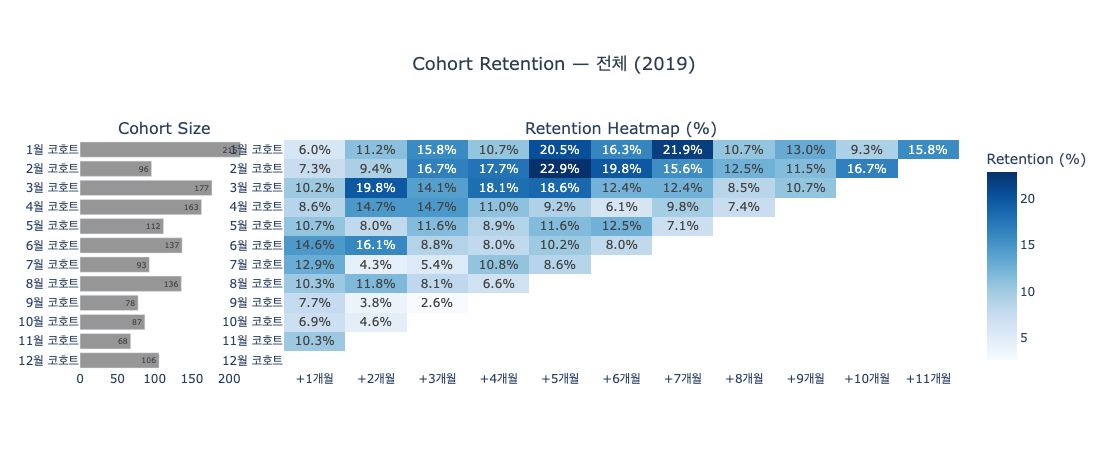

In [7]:
draw_cohort_heatmap(cohort_pivot, cohort_pct, "Cohort Retention — 전체 (2019)")

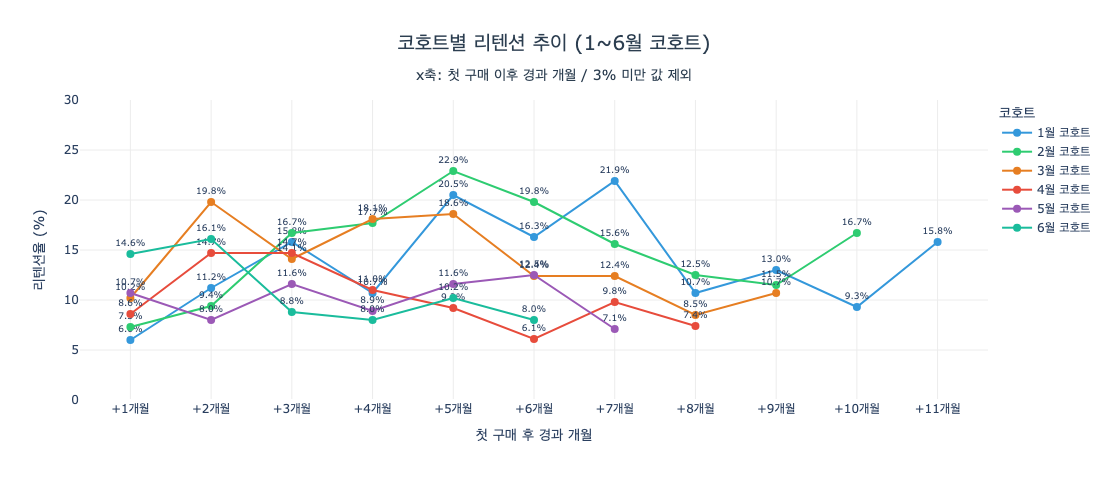

In [8]:
colors = [
    '#3498db', '#2ecc71', '#e67e22', '#e74c3c',
    '#9b59b6', '#1abc9c'
]

heatmap_vals = cohort_pct.drop(columns=[0], errors="ignore")
y_labels = [f"{i}월 코호트" for i in heatmap_vals.index]

# 초기 6개 코호트만 (관측 기간 충분)
early_cohorts = list(range(min(6, len(y_labels))))

fig = go.Figure()

for idx, cohort_idx in enumerate(early_cohorts):
    label = y_labels[cohort_idx]
    y_vals = heatmap_vals.iloc[cohort_idx].values
    x_vals = [f"+{c}개월" for c in heatmap_vals.columns]
    filtered = [v if (not np.isnan(v) and v >= 3) else None for v in y_vals]
    text_vals = [f"{v:.1f}%" if v is not None else "" for v in filtered]

    fig.add_trace(go.Scatter(
        x=x_vals,
        y=filtered,
        mode='lines+markers+text',
        name=label,
        line=dict(color=colors[idx % len(colors)], width=2),
        marker=dict(size=8),
        text=text_vals,
        textposition='top center',
        textfont=dict(size=9),
        connectgaps=False
    ))

fig.update_layout(
    title=dict(
        text='코호트별 리텐션 추이 (1~6월 코호트)<br><sub>x축: 첫 구매 이후 경과 개월 / 3% 미만 값 제외</sub>',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')
    ),
    xaxis_title='첫 구매 후 경과 개월',
    yaxis_title='리텐션율 (%)',
    plot_bgcolor='white',
    xaxis=dict(gridcolor='#ececec'),
    yaxis=dict(gridcolor='#ececec', range=[0, 30]),
    legend=dict(title='코호트', orientation='v', x=1.01, y=1),
    height=480
)
fig.show()

In [9]:
avg_by_lag = (
    cohort_pct.drop(columns=[0])
    .mean()
    .reset_index()
    .rename(columns={"month_diff": "경과월", 0: "평균_리텐션율"})
)
avg_by_lag.columns = ["경과월", "평균_리텐션율"]
avg_by_lag["평균_리텐션율"] = avg_by_lag["평균_리텐션율"].round(1)

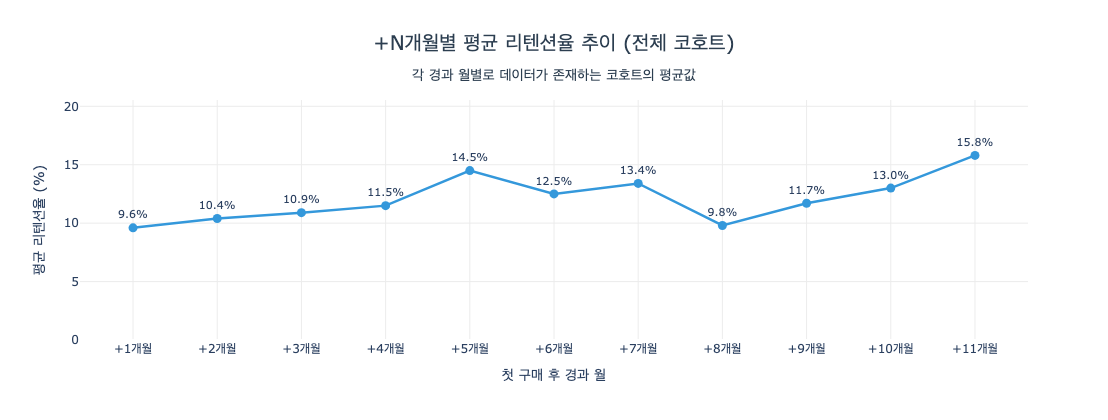

In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=avg_by_lag["경과월"],
    y=avg_by_lag["평균_리텐션율"],
    mode="lines+markers+text",
    text=[f"{v}%" for v in avg_by_lag["평균_리텐션율"]],
    textposition="top center",
    textfont=dict(size=11),
    line=dict(color="#3498db", width=2.5),
    marker=dict(size=9, color="#3498db"),
))

fig.update_layout(
    title=dict(
        text="+N개월별 평균 리텐션율 추이 (전체 코호트)<br>"
             "<sub>각 경과 월별로 데이터가 존재하는 코호트의 평균값</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    xaxis=dict(
        title="첫 구매 후 경과 월",
        tickvals=avg_by_lag["경과월"].tolist(),
        ticktext=[f"+{n}개월" for n in avg_by_lag["경과월"].tolist()],
        gridcolor="#ececec"
    ),
    yaxis=dict(title="평균 리텐션율 (%)", gridcolor="#ececec", range=[0, avg_by_lag["평균_리텐션율"].max() * 1.3]),
    plot_bgcolor="white",
    height=420
)
fig.show()

### 인사이트

**전체 코호트 히트맵**
- 리텐션은 대체로 6-23% 범위 — 2월 코호트 +5개월(22.9%)이 최고, 1·2월 코호트의 +1개월(6.0%, 7.3%)이 최저
- **1-3월 초기 코호트**(개별 평균 13-15%)가 **4-6월 중기 코호트**(개별 평균 10-11%)보다 안정적인 리텐션을 보임
- 7월 이후 후기 코호트는 관측 기간이 짧아 장기 비교가 어렵고, 관측 범위 내 값도 3-13%로 변동폭이 크고 불규칙하여 안정적인 패턴을 파악하기 어렵다

**코호트별 추이 (1-6월)**
- **1·2월 코호트가 가장 안정적**: 전 기간 평균 리텐션이 각각 13.7%, 15.0%로 6개 코호트 중 최상위
- 피크 시점이 코호트마다 상이함 — 1월(+7개월 21.9%), 2월(+5개월 22.9%), 3월(+2개월 19.8%), 6월(+2개월 16.1%)
- **+2개월 피크가 3·6월 코호트에 공통 출현** (4월도 +2·3개월 공동 최고 14.7%) — 첫 구매 후 2개월 시점에 복귀 유인이 존재할 가능성
- 4·5월 코호트는 전 기간 평균 10% 수준에 그침 — 관측 기간 제한 및 해당 시기 유입 고객의 재구매 의향 저하 가능성

**+N개월별 평균 리텐션 추이**
- **+5개월에서 14.5%로 전반기 최고치** — 복귀율은 +1개월(9.6%) 이후 완만히 상승해 +5개월에서 정점 형성
- **+7개월에서도 13.4%로 2차 피크** — +6개월(12.5%) 소폭 감소 후 반등하는 패턴, 반기 주기 복귀 가능성
- +11개월(15.8%)은 데이터 기간상 1월 코호트에서만 관측 가능 — 2019년 1년치 데이터에서 12개월 추적이 가능한 유일한 코호트이므로 장기 잔존 고객 특성의 참고값으로만 활용

---
## 4. 마케팅 비용과 재구매율

마케팅 비용 수준에 따라 유입된 고객의 재구매율을 비교한다.  
비용이 높은 날 유입된 고객이 장기적으로 더 높은 재구매율을 보이는지 확인한다.

> **가설**: 마케팅 비용이 높은 날 유입된 고객일수록 재구매율이 높을 것이다.

In [11]:
# 고객별 첫 구매일 기준 채널별 마케팅비용
cost_detail = pd.read_sql(
    """
    SELECT
        v.고객ID,
        v.온라인비용,
        v.오프라인비용,
        v.온라인비용 + v.오프라인비용 AS 총마케팅비용
    FROM orders_master v
    INNER JOIN (
        SELECT 고객ID, MIN(거래날짜) AS first_date
        FROM orders_master
        GROUP BY 고객ID
    ) f ON v.고객ID = f.고객ID AND v.거래날짜 = f.first_date
    GROUP BY v.고객ID, v.온라인비용, v.오프라인비용
    """,
    engine
)
cost_detail.head()

,고객ID,온라인비용,오프라인비용,총마케팅비용
0,USER_1358,2424.5,4500,6924.5
1,USER_0190,2424.5,4500,6924.5
2,USER_0066,2424.5,4500,6924.5
3,USER_0345,2424.5,4500,6924.5
4,USER_0683,2424.5,4500,6924.5


In [12]:
cost_detail.describe().round(2)

,온라인비용,오프라인비용,총마케팅비용
count,1468.00,1468.00,1468.00
mean,1887.91,2819.01,4706.92
std,807.80,1038.69,1541.01
min,320.25,500.00,820.25
25%,1253.24,2000.00,3767.58
50%,1827.02,3000.00,4668.34
75%,2431.73,3500.00,5553.41
max,4556.93,5000.00,8555.30


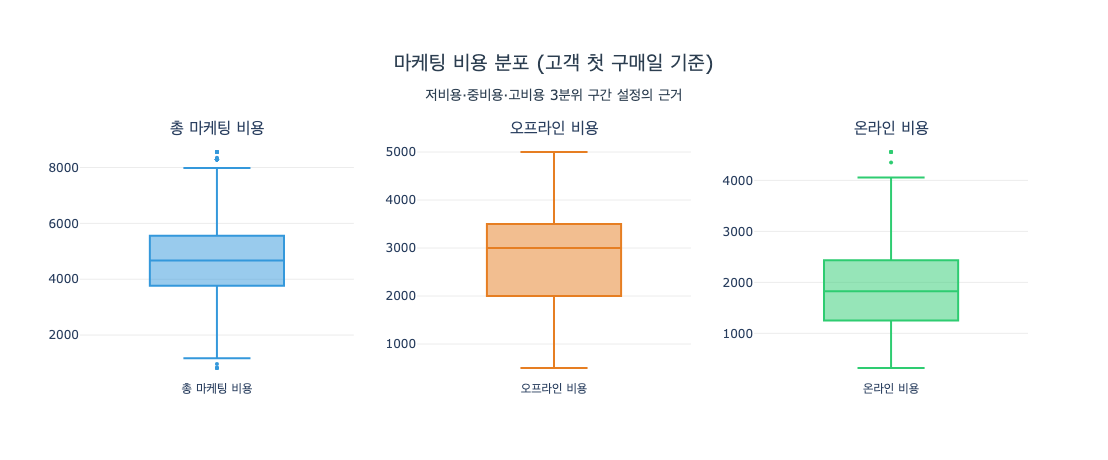

In [13]:
cols = [
    ("총마케팅비용", "총 마케팅 비용"),
    ("오프라인비용", "오프라인 비용"),
    ("온라인비용",  "온라인 비용"),
]
colors = ["#3498db", "#e67e22", "#2ecc71"]

fig = make_subplots(rows=1, cols=3, subplot_titles=[c[1] for c in cols])

for ci, (col, label) in enumerate(cols, 1):
    fig.add_trace(
        go.Box(
            y=cost_detail[col],
            name=label,
            boxpoints="outliers",
            marker=dict(color=colors[ci - 1], size=4),
            line=dict(color=colors[ci - 1]),
            showlegend=False,
        ),
        row=1, col=ci,
    )

fig.update_layout(
    title=dict(
        text="마케팅 비용 분포 (고객 첫 구매일 기준)<br>"
             "<sub>저비용·중비용·고비용 3분위 구간 설정의 근거</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50"),
    ),
    plot_bgcolor="white",
    height=460,
    margin=dict(t=140)
)
fig.update_yaxes(gridcolor="#ececec")
fig.show()

In [14]:
cost_detail["비용구간"] = pd.qcut(
    cost_detail["총마케팅비용"], q=3,
    labels=["저비용","중비용","고비용"]
)

df_mkt_cohort = df.merge(cost_detail[["고객ID","비용구간"]], on="고객ID")

cohort_by_cost = {}
for seg in ["저비용","중비용","고비용"]:
    sub = df_mkt_cohort[df_mkt_cohort["비용구간"] == seg]
    cost_min = cost_detail[cost_detail["비용구간"] == seg]["총마케팅비용"].min()
    cost_max = cost_detail[cost_detail["비용구간"] == seg]["총마케팅비용"].max()
    pivot, pct = build_cohort(sub)
    cohort_by_cost[seg] = {"pivot": pivot, "pct": pct}
    print(f"{seg}: {sub['고객ID'].nunique()}명 / 마케팅 비용: {cost_min:,.0f} ~ {cost_max:,.0f}")

저비용: 489명 / 마케팅 비용: 820 ~ 4,189
중비용: 490명 / 마케팅 비용: 4,227 ~ 5,223
고비용: 489명 / 마케팅 비용: 5,231 ~ 8,555


In [15]:
cost_detail["오프라인구간"] = pd.qcut(
    cost_detail["오프라인비용"], q=3, labels=["저비용", "중비용", "고비용"]
)
cost_detail["온라인구간"] = pd.qcut(
    cost_detail["온라인비용"], q=3, labels=["저비용", "중비용", "고비용"]
)

cohort_by_offline = {}
df_offline = df.merge(cost_detail[["고객ID", "오프라인구간"]], on="고객ID")
for seg in ["저비용", "중비용", "고비용"]:
    sub = df_offline[df_offline["오프라인구간"] == seg]
    pivot, pct = build_cohort(sub)
    cohort_by_offline[seg] = {"pivot": pivot, "pct": pct}
    cost_min = cost_detail[cost_detail["오프라인구간"] == seg]["오프라인비용"].min()
    cost_max = cost_detail[cost_detail["오프라인구간"] == seg]["오프라인비용"].max()
    print(f"오프라인 {seg}: {sub['고객ID'].nunique()}명  ({cost_min:,.0f} ~ {cost_max:,.0f})")

print()

cohort_by_online = {}
df_online = df.merge(cost_detail[["고객ID", "온라인구간"]], on="고객ID")
for seg in ["저비용", "중비용", "고비용"]:
    sub = df_online[df_online["온라인구간"] == seg]
    pivot, pct = build_cohort(sub)
    cohort_by_online[seg] = {"pivot": pivot, "pct": pct}
    cost_min = cost_detail[cost_detail["온라인구간"] == seg]["온라인비용"].min()
    cost_max = cost_detail[cost_detail["온라인구간"] == seg]["온라인비용"].max()
    print(f"온라인 {seg}: {sub['고객ID'].nunique()}명  ({cost_min:,.0f} ~ {cost_max:,.0f})")

오프라인 저비용: 626명  (500 ~ 2,500)
오프라인 중비용: 363명  (3,000 ~ 3,000)
오프라인 고비용: 479명  (3,500 ~ 5,000)

온라인 저비용: 498명  (320 ~ 1,477)
온라인 중비용: 482명  (1,478 ~ 2,223)
온라인 고비용: 488명  (2,228 ~ 4,557)


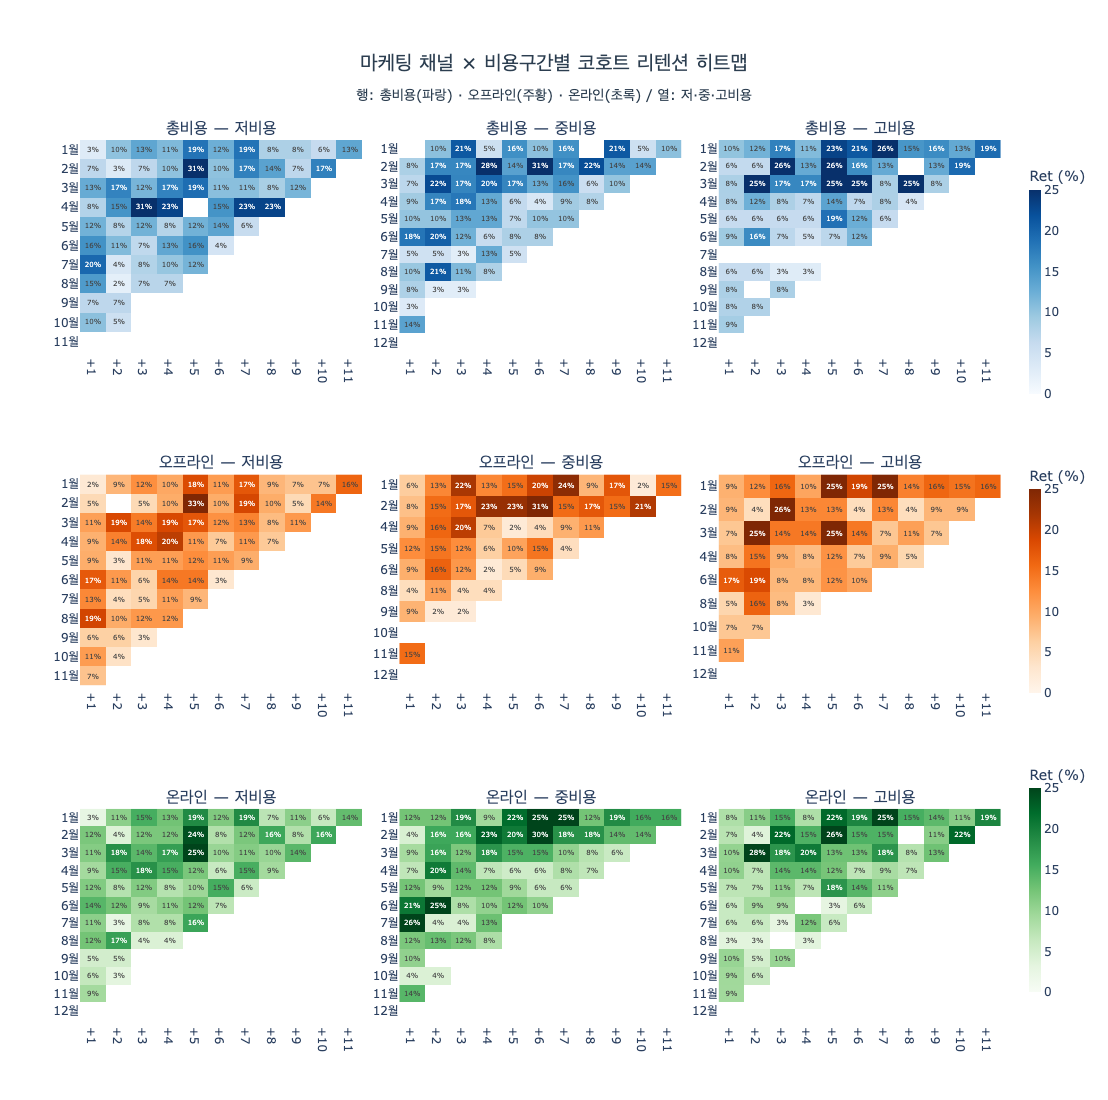

In [16]:
channel_data = [
    ("총비용",   cohort_by_cost,    "Blues"),
    ("오프라인", cohort_by_offline, "Oranges"),
    ("온라인",   cohort_by_online,  "Greens"),
]
segs = ["저비용", "중비용", "고비용"]
colorbar_y = {1: 0.84, 2: 0.50, 3: 0.16}

specs = [[{"type": "heatmap"}] * 3 for _ in range(3)]
subplot_titles = [
    f"{ch} — {seg}"
    for ch, _, __ in channel_data
    for seg in segs
]

fig = make_subplots(
    rows=3, cols=3,
    specs=specs,
    subplot_titles=subplot_titles,
    vertical_spacing=0.14,
    horizontal_spacing=0.04,
)

for ri, (channel, data_dict, colorscale) in enumerate(channel_data, 1):
    for ci, seg in enumerate(segs, 1):
        data = data_dict[seg]
        hmap = data["pct"].drop(columns=[0], errors="ignore")
        y_labels = [f"{i}월" for i in hmap.index]
        x_labels = [f"+{c}" for c in hmap.columns]
        custom_text = [
            [f"{v:.0f}%" if (v == v and v > 0) else "" for v in row]
            for row in hmap.values
        ]
        show_scale = (ci == 3)
        fig.add_trace(
            go.Heatmap(
                z=hmap.values,
                x=x_labels,
                y=y_labels,
                colorscale=colorscale,
                text=custom_text,
                texttemplate="%{text}",
                textfont=dict(size=7),
                showscale=show_scale,
                colorbar=dict(
                    x=1.02, len=0.28, y=colorbar_y[ri],
                    title=dict(text="Ret (%)"),
                    thickness=12,
                ),
                zmin=0,
                zmax=25,
            ),
            row=ri, col=ci,
        )

fig.update_yaxes(autorange="reversed")
fig.update_layout(
    title=dict(
        text="마케팅 채널 × 비용구간별 코호트 리텐션 히트맵<br>"
             "<sub>행: 총비용(파랑) · 오프라인(주황) · 온라인(초록) / 열: 저·중·고비용</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50"),
    ),
    plot_bgcolor="white",
    height=1100,
    width=1400,
    margin=dict(t=140),
)
fig.show()

### 인사이트

- **단기(+1-3개월)**: 저비용·중비용·고비용 간 리텐션 차이가 미미함 (8-12% 범위 혼재) — 마케팅 비용이 높은 날 유입된 고객이 단기적으로 더 많이 돌아오지는 않음
- **장기(+6개월, 총비용 기준)**: 고비용 15.6% > 중비용 12.6% > 저비용 11.1% 순으로 명확한 서열 형성 — 비용 수준별 4.5%p 차이
- 가설("마케팅 비용이 높은 날 유입될수록 재구매율이 높다")은 **단기엔 지지되지 않으나 장기적으로 일부 지지됨**
- 고비용 마케팅의 효과는 즉각적인 재방문보다 장기 잔존율에서 드러나는 구조 — 단기 ROAS만으로 채널 효율을 평가하면 고비용 캠페인을 과소평가할 수 있음
- **채널별 분리**: 오프라인 중비용 구간이 사실상 $3,000/일 단일값으로 수렴(qcut 구간 분리 결과) — 데이터 분포 특성상 의미 있는 구간 분리가 불가하여 오프라인 채널 구간 분석은 유효하지 않다. 온라인에서도 중비용(15.2%)이 고비용(12.4%)보다 높게 나타나 총비용 기준 패턴과 역전되나, 표본 노이즈를 배제하기 어려워 채널별 결론은 내리기 어렵다.

---
## 5. 카테고리별 리텐션 분석

매출 상위 카테고리 구매 고객의 코호트 리텐션 히트맵과, 성별별 카테고리 재구매율 추이를 함께 확인한다.

| 분석 | 내용 |
|------|------|
| 히트맵 | 카테고리별 코호트 리텐션 (첫 구매월 기준 잔존율) |
| 추이 A | 고객 첫 구매월 기준 — 이후 월에도 구매(전 카테고리)한 비율 |
| 추이 B | 카테고리 첫 구매월 기준 — 같은 카테고리를 재구매한 비율 |

In [17]:
# 매출 상위 5개 카테고리 — curve_a/curve_b SQL 내부 top_cats와 기준 통일 (고객 수 기준)
top_cats = pd.read_sql(
    """
    SELECT 제품카테고리
    FROM orders_master
    GROUP BY 제품카테고리
    ORDER BY COUNT(DISTINCT 고객ID) DESC
    LIMIT 5
    """,
    engine
)["제품카테고리"].tolist()

# 고객-카테고리-월 데이터
df_cat = pd.read_sql(
    """
    WITH first_purchases AS (
        SELECT 고객ID, MIN(월) AS first_month
        FROM orders_master
        GROUP BY 고객ID
    )
    SELECT o.고객ID, o.월, o.제품카테고리,
           f.first_month,
           o.월 - f.first_month AS month_diff
    FROM orders_master o
    LEFT JOIN first_purchases f ON o.고객ID = f.고객ID
    """,
    engine
)

df_cat = df_cat.drop_duplicates(["고객ID", "월", "제품카테고리"])
top_cats

['Apparel', 'Nest-USA', 'Office', 'Drinkware', 'Lifestyle']

In [18]:
df_cat.head()

,고객ID,월,제품카테고리,first_month,month_diff
0,USER_1358,1,Nest-USA,1,0
2,USER_1358,1,Office,1,0
3,USER_1358,1,Apparel,1,0
4,USER_1358,1,Bags,1,0
6,USER_1358,1,Drinkware,1,0


In [19]:
cohort_by_cat = {}
for cat in top_cats:
    cat_customers = set(df_cat[df_cat["제품카테고리"] == cat]["고객ID"])
    df_sub = df_cat[df_cat["고객ID"].isin(cat_customers)]
    pivot, pct = build_cohort(df_sub)
    cohort_by_cat[cat] = {"pivot": pivot, "pct": pct}
    print(f"{cat}: {len(cat_customers)}명")

Apparel: 1323명
Nest-USA: 1260명
Office: 1103명
Drinkware: 919명
Lifestyle: 817명


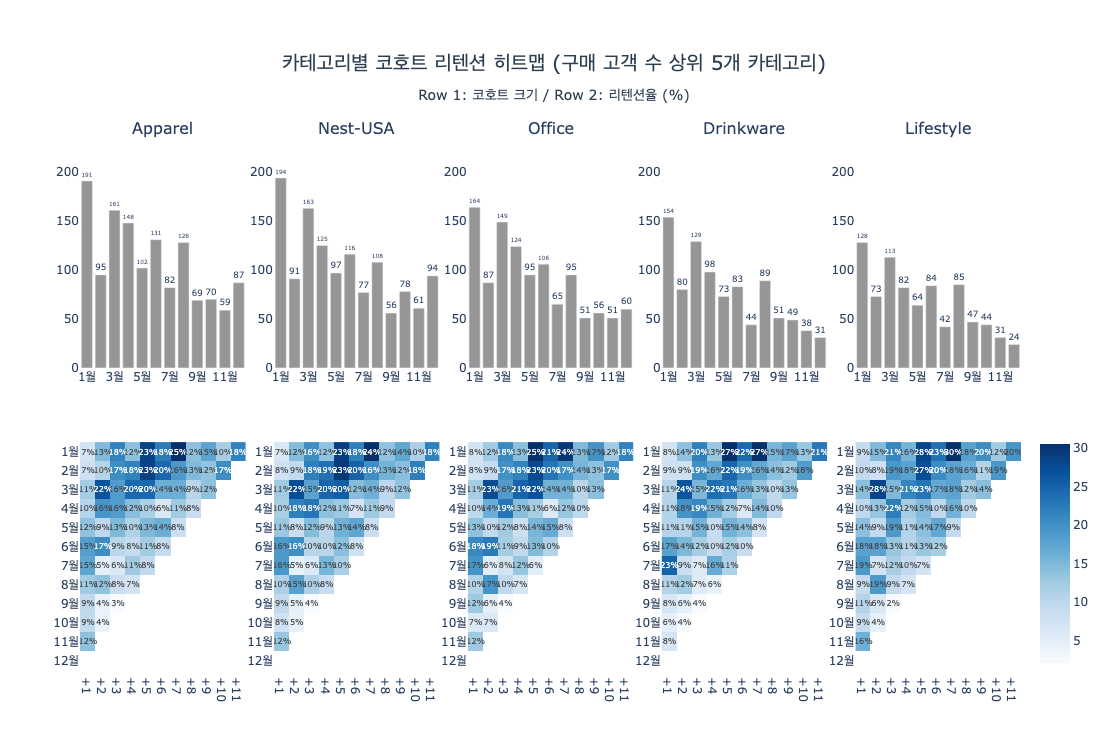

In [20]:
specs = [[{"type": "xy"}] * 5, [{"type": "heatmap"}] * 5]

fig = make_subplots(
    rows=2, cols=5,
    specs=specs,
    subplot_titles=top_cats,
    vertical_spacing=0.14,
    horizontal_spacing=0.03
)

max_size = max(data["pivot"][0].max() for data in cohort_by_cat.values())

for ci, cat in enumerate(top_cats, 1):
    data = cohort_by_cat[cat]
    hmap = data["pct"].drop(columns=[0], errors="ignore")
    sizes = data["pivot"][0].reindex(hmap.index).values
    cat_y = [f"{i}월" for i in hmap.index]
    cat_x = [f"+{c}" for c in hmap.columns]

    fig.add_trace(go.Bar(
        x=cat_y,
        y=sizes,
        text=sizes,
        textposition="outside",
        marker_color="rgb(150,150,150)",
        showlegend=False
    ), row=1, col=ci)

    fig.add_trace(go.Heatmap(
        z=hmap.values,
        x=cat_x,
        y=cat_y,
        colorscale="Blues",
        text=[[f"{v:.0f}%" if (v == v and v > 0) else "" for v in row] for row in hmap.values],
        texttemplate="%{text}",
        textfont=dict(size=8),
        showscale=(ci == 5),
        colorbar=dict(x=1.01, len=0.45, y=0.22),
        zmin=0
    ), row=2, col=ci)

fig.update_yaxes(range=[0, max_size * 1.2], row=1)
fig.update_yaxes(autorange="reversed", row=2)

fig.update_layout(
    title=dict(
        text="카테고리별 코호트 리텐션 히트맵 (구매 고객 수 상위 5개 카테고리)<br>"
             "<sub>Row 1: 코호트 크기 / Row 2: 리텐션율 (%)</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    plot_bgcolor="white",
    height=750,
    width=1500,
    margin=dict(t=140)
)
fig.show()

In [21]:
# A: 고객 첫 구매월 기준 코호트 — top5 카테고리 구매 경험 고객이 이후 월에도 구매(전 카테고리)하는 비율
curve_a = pd.read_sql(
    """
    WITH first_month AS (
        SELECT
            고객ID,
            MIN(월) AS first_month
        FROM orders_master
        GROUP BY 고객ID
    ),
    cat_counts AS (
        SELECT
            성별,
            제품카테고리,
            COUNT(DISTINCT 고객ID) AS cnt
        FROM orders_master
        GROUP BY 성별, 제품카테고리
    ),
    top_cats AS (
        SELECT 성별, 제품카테고리
        FROM (
            SELECT 성별, 제품카테고리,
                   ROW_NUMBER() OVER (
                       PARTITION BY 성별
                       ORDER BY cnt DESC
                   ) AS rn
            FROM cat_counts
        ) ranked
        WHERE rn <= 5
    ),
    cat_customers AS (
        SELECT DISTINCT o.고객ID, o.성별, o.제품카테고리, f.first_month
        FROM orders_master o
        JOIN top_cats t ON o.성별 = t.성별 AND o.제품카테고리 = t.제품카테고리
        JOIN first_month f ON o.고객ID = f.고객ID
    ),
    lags AS (
        SELECT 1 AS 경과월 UNION SELECT 2 UNION SELECT 3 UNION SELECT 4 UNION SELECT 5
        UNION SELECT 6 UNION SELECT 7 UNION SELECT 8 UNION SELECT 9 UNION SELECT 10
    ),
    monthly_buyers AS (
        SELECT DISTINCT 고객ID, 월
        FROM orders_master
    ),
    eligible AS (
        SELECT
            c.성별,
            c.제품카테고리,
            l.경과월 AS 구매후_경과월,
            CASE WHEN m.고객ID IS NOT NULL THEN 1 ELSE 0 END AS 재구매
        FROM cat_customers c
        CROSS JOIN lags l
        LEFT JOIN monthly_buyers m
            ON  c.고객ID = m.고객ID
            AND m.월    = c.first_month + l.경과월
        WHERE c.first_month + l.경과월 <= 12
    )
    SELECT
        성별,
        제품카테고리,
        구매후_경과월,
        ROUND(AVG(재구매) * 100, 1) AS 재구매율
    FROM eligible
    GROUP BY 성별, 제품카테고리, 구매후_경과월
    ORDER BY 성별, 제품카테고리, 구매후_경과월
    """,
    engine
)

# B: 카테고리별 첫 구매월 기준 코호트 — 같은 카테고리를 첫 구매 후 N개월에도 재구매하는 비율
curve_b = pd.read_sql(
    """
    WITH cat_first_month AS (
        SELECT
            고객ID,
            성별,
            제품카테고리,
            MIN(월) AS cat_first_month
        FROM orders_master
        GROUP BY 고객ID, 성별, 제품카테고리
    ),
    cat_counts AS (
        SELECT
            성별,
            제품카테고리,
            COUNT(DISTINCT 고객ID) AS cnt
        FROM cat_first_month
        GROUP BY 성별, 제품카테고리
    ),
    top_cats AS (
        SELECT 성별, 제품카테고리
        FROM (
            SELECT 성별, 제품카테고리,
                   ROW_NUMBER() OVER (
                       PARTITION BY 성별
                       ORDER BY cnt DESC
                   ) AS rn
            FROM cat_counts
        ) ranked
        WHERE rn <= 5
    ),
    cat_purchases AS (
        SELECT DISTINCT 고객ID, 성별, 제품카테고리, 월
        FROM orders_master
    ),
    lags AS (
        SELECT 1 AS 경과월 UNION SELECT 2 UNION SELECT 3 UNION SELECT 4 UNION SELECT 5
        UNION SELECT 6 UNION SELECT 7 UNION SELECT 8 UNION SELECT 9 UNION SELECT 10
    ),
    eligible AS (
        SELECT
            f.성별,
            f.제품카테고리,
            l.경과월 AS 구매후_경과월,
            CASE WHEN p.고객ID IS NOT NULL THEN 1 ELSE 0 END AS 재구매
        FROM cat_first_month f
        JOIN top_cats t ON f.성별 = t.성별 AND f.제품카테고리 = t.제품카테고리
        CROSS JOIN lags l
        LEFT JOIN cat_purchases p
            ON  f.고객ID        = p.고객ID
            AND f.제품카테고리   = p.제품카테고리
            AND p.월            = f.cat_first_month + l.경과월
        WHERE f.cat_first_month + l.경과월 <= 12
    )
    SELECT
        성별,
        제품카테고리,
        구매후_경과월,
        ROUND(AVG(재구매) * 100, 1) AS 재구매율
    FROM eligible
    GROUP BY 성별, 제품카테고리, 구매후_경과월
    ORDER BY 성별, 제품카테고리, 구매후_경과월
    """,
    engine
)

gender_top_cats = (
    curve_a.drop_duplicates(["성별", "제품카테고리"])
    [["성별", "제품카테고리"]]
)
curve_a.head(10)

,성별,제품카테고리,구매후_경과월,재구매율
0,남,Apparel,1,10.0
1,남,Apparel,2,12.5
2,남,Apparel,3,12.6
3,남,Apparel,4,13.3
4,남,Apparel,5,14.9
5,남,Apparel,6,15.2
6,남,Apparel,7,17.0
7,남,Apparel,8,10.0
8,남,Apparel,9,14.0
9,남,Apparel,10,10.2


In [22]:
# 성별별 top1 카테고리 구매 고객의 코호트 리텐션 데이터 로드
# f-string으로 SQL 직접 삽입 — 실습 환경(내부 DB, 고정값)이므로 파라미터 바인딩 생략
top1_female = gender_top_cats[gender_top_cats["성별"] == "여"]["제품카테고리"].iloc[0]
top1_male = gender_top_cats[gender_top_cats["성별"] == "남"]["제품카테고리"].iloc[0]

cohort_top1 = {}
for gender, cat in [("여", top1_female), ("남", top1_male)]:
    df_sub = pd.read_sql(
        f"""
        WITH first_purchases AS (
            SELECT 고객ID, MIN(월) AS first_month
            FROM orders_master
            GROUP BY 고객ID
        ),
        cat_buyers AS (
            SELECT DISTINCT 고객ID
            FROM orders_master
            WHERE 성별 = '{gender}' AND 제품카테고리 = '{cat}'
        )
        SELECT DISTINCT o.고객ID, o.월,
               f.first_month,
               o.월 - f.first_month AS month_diff
        FROM orders_master o
        JOIN first_purchases f ON o.고객ID = f.고객ID
        JOIN cat_buyers c ON o.고객ID = c.고객ID
        WHERE o.성별 = '{gender}'
        """,
        engine
    )
    df_sub = df_sub.drop_duplicates(["고객ID", "월"])
    pivot, pct = build_cohort(df_sub)
    cohort_top1[gender] = {"pivot": pivot, "pct": pct, "cat": cat}
    print(f"{gender}성 top1 [{cat}]: {df_sub['고객ID'].nunique()}명")

여성 top1 [Apparel]: 837명
남성 top1 [Apparel]: 486명


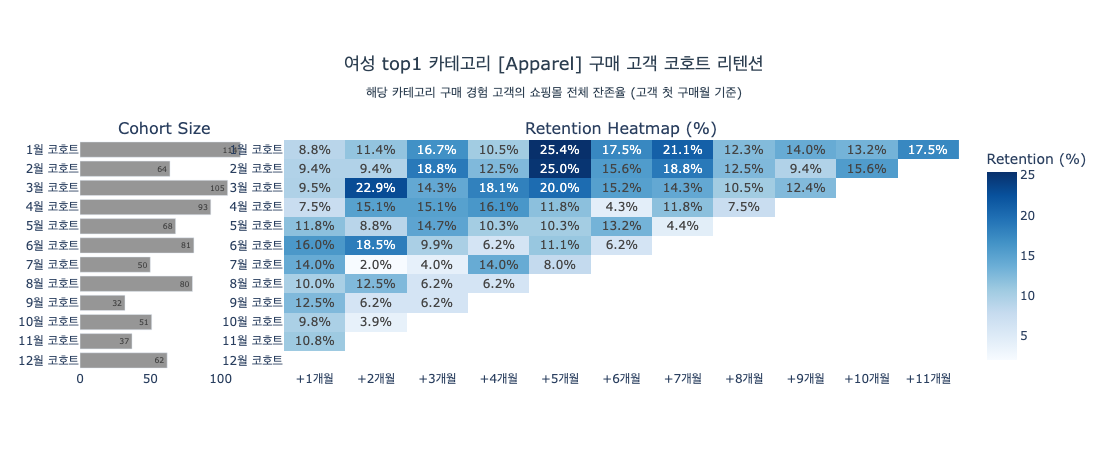

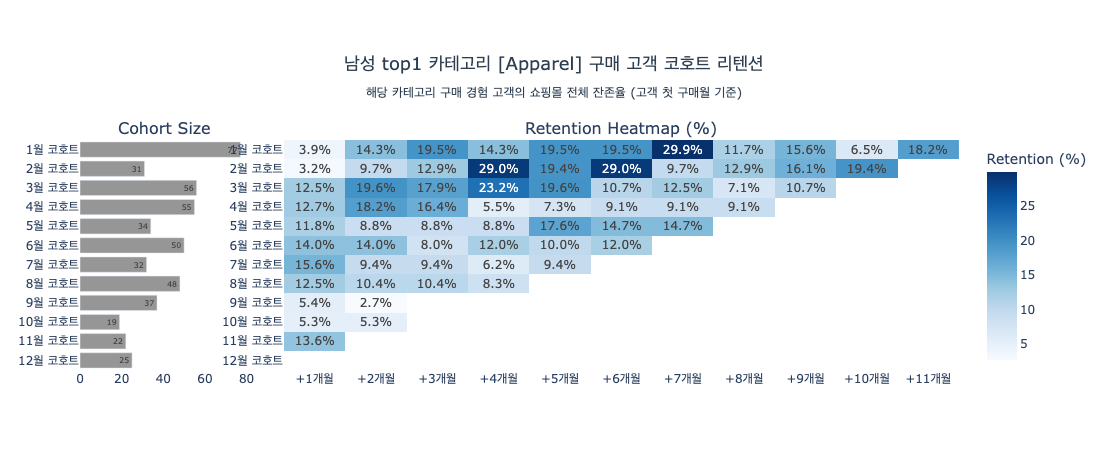

In [23]:
for gender, data in cohort_top1.items():
    label = "여성" if gender == "여" else "남성"
    draw_cohort_heatmap(
        data["pivot"], data["pct"],
        f"{label} top1 카테고리 [{data['cat']}] 구매 고객 코호트 리텐션"
        f"<br><sub>해당 카테고리 구매 경험 고객의 쇼핑몰 전체 잔존율 (고객 첫 구매월 기준)</sub>"
    )

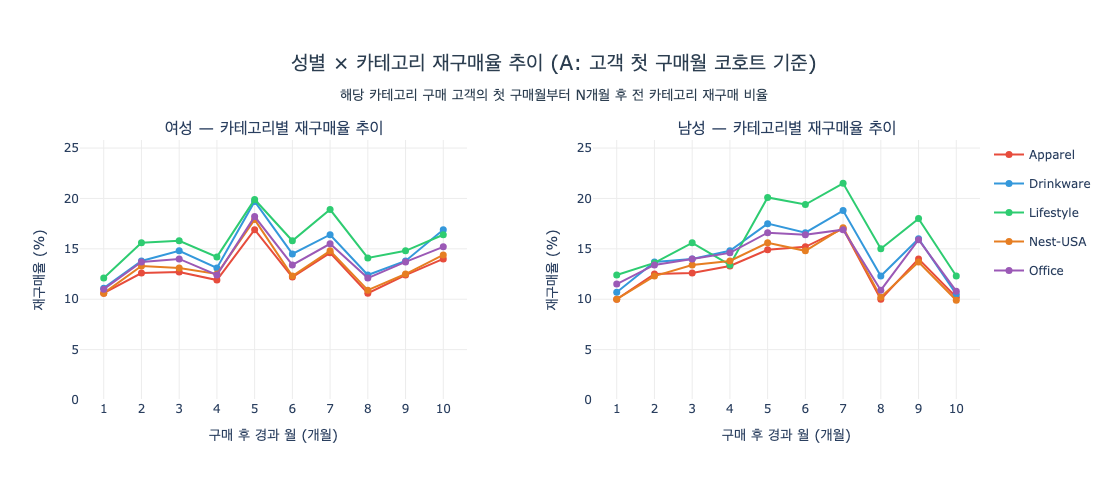

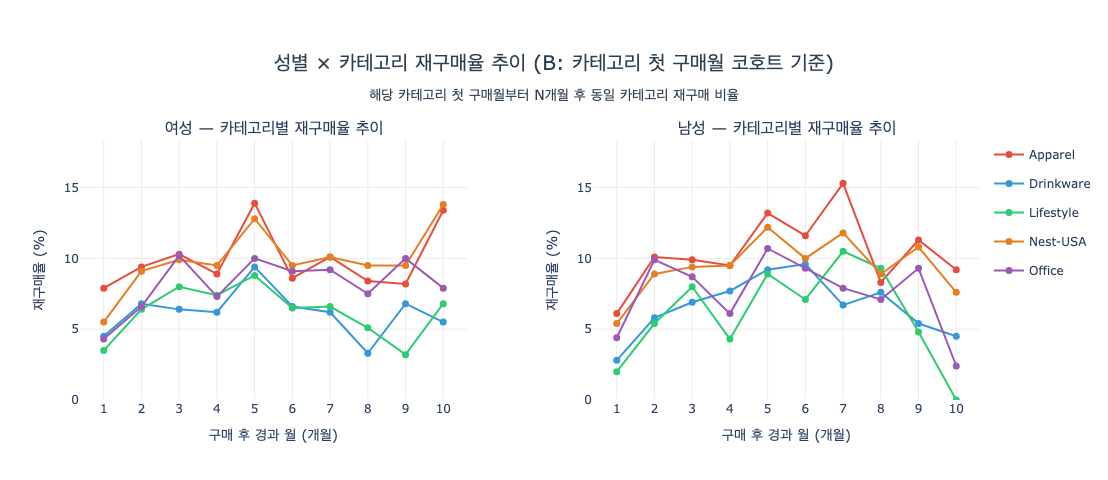

In [24]:
COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

def draw_retention_curve(curve, title):
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("여성 — 카테고리별 재구매율 추이", "남성 — 카테고리별 재구매율 추이"),
        horizontal_spacing=0.14
    )
    for col_idx, gender in enumerate(["여", "남"], 1):
        cats = gender_top_cats[gender_top_cats["성별"] == gender]["제품카테고리"].tolist()
        for ci, cat in enumerate(cats):
            sub = curve[(curve["성별"] == gender) & (curve["제품카테고리"] == cat)]
            fig.add_trace(go.Scatter(
                x=sub["구매후_경과월"],
                y=sub["재구매율"],
                mode="lines+markers",
                name=cat,
                line=dict(color=COLORS[ci % len(COLORS)], width=2),
                marker=dict(size=7),
                legendgroup=cat,
                showlegend=(col_idx == 1),
            ), row=1, col=col_idx)

    y_max = curve["재구매율"].max() * 1.2
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")),
        plot_bgcolor="white", height=480, width=1000,
        legend=dict(orientation="v", x=1.01, y=1),
        margin=dict(t=140)
    )
    for i in range(1, 3):
        fig.update_xaxes(
            title_text="구매 후 경과 월 (개월)", tickvals=list(range(1, 11)),
            gridcolor="#ececec", row=1, col=i
        )
        fig.update_yaxes(
            title_text="재구매율 (%)", gridcolor="#ececec",
            range=[0, y_max], row=1, col=i
        )
    fig.show()

draw_retention_curve(
    curve_a,
    "성별 × 카테고리 재구매율 추이 (A: 고객 첫 구매월 코호트 기준)<br>"
    "<sub>해당 카테고리 구매 고객의 첫 구매월부터 N개월 후 전 카테고리 재구매 비율</sub>"
)
draw_retention_curve(
    curve_b,
    "성별 × 카테고리 재구매율 추이 (B: 카테고리 첫 구매월 코호트 기준)<br>"
    "<sub>해당 카테고리 첫 구매월부터 N개월 후 동일 카테고리 재구매 비율</sub>"
)

### 인사이트

#### 쇼핑몰 복귀 주기 (curve_a)
*해당 카테고리 구매 경험 고객이 첫 구매월 기준 N개월 후 쇼핑몰 전체에서 잔존하는 비율*

남성과 여성 모두 5개 카테고리 전반에서 피크 시점이 카테고리에 무관하게 일치한다.

| | 피크 시점 | 카테고리별 잔존율 피크 |
|---|---|---|
| 남성 | +7개월 | Lifestyle 21.5% / Drinkware 18.8% / Nest-USA 17.1% / Apparel 17.0% / Office 16.9% |
| 여성 | +5개월 | Lifestyle 19.9% / Drinkware 19.7% / Office 18.2% / Nest-USA 17.9% / Apparel 16.9% |

> 카테고리와 무관하게 성별 주기가 일정하므로, 개인화 타이밍 기준을 성별로 단순화할 수 있다.  
> 여성(+5개월)이 남성(+7개월)보다 주기가 짧은 것은 여성 상위 카테고리가 Apparel·Drinkware 등 패션·생활용품 중심으로 소비 사이클 자체가 짧은 것과 연관될 수 있다.

---

#### 카테고리별 재구매 주기 (curve_b)
*카테고리 첫 구매월 기준 N개월 후 동일 카테고리를 재구매한 비율*

curve_b의 로컬 피크 위치를 보면 카테고리마다 고유한 재구매 주기가 나타난다.

| 성별 | 카테고리 | 피크 시점 | 주기 |
|---|---|---|---|
| 여성 | Office | +3 → +5 → +7 → +9개월 | **2개월** (전 구간 가장 규칙적) |
| 여성 | Apparel | +3 → +5 → +7 → +10개월 | **2개월** |
| 여성 | Nest-USA | +3 → +5 → +7 → +10개월 | **2개월** |
| 여성 | Lifestyle | +3 → +5 → +7 → +10개월 | **2개월** |
| 여성 | Drinkware | +2 → +5 → +9개월 | **3-4개월** |
| 남성 | Office | +2 → +5 → +9개월 | **3-4개월** (가장 뚜렷) |
| 남성 | Apparel | +2 → +5 → +7 → +9개월 | 초기 3개월 → 이후 2개월 |
| 남성 | Lifestyle | +3 → +5 → +7개월 | **2개월** |
| 남성 | Nest-USA | +5 → +7 → +9개월 | **2개월** |
| 남성 | Drinkware | 점진 상승 후 +6개월 최고 | 주기 불명확 |

*⚠️ 데이터 한계: 1년치 기준이므로 +8개월 이후 lag는 관측 코호트 수가 줄어 주기 해석 시 참고용으로 활용*

> **여성은 대부분 2개월 주기**, **남성 Office·여성 Drinkware는 3-4개월 주기**로 재구매가 반복된다.  
> 카테고리 구매 이력이 있는 고객에 한해, 해당 주기 직전 시점에 알림을 보내는 것이 효율적이다.

---

#### 카테고리 충성도 (curve_a vs curve_b 격차)
*잔존율(A)과 카테고리 재구매율(B) 피크의 차이 — 격차가 클수록 쇼핑몰엔 남지만 그 카테고리로는 돌아오지 않음*

**남성**

| 카테고리 | 잔존율 피크 (A) | 재구매율 피크 (B) | 격차 |
|---|---|---|---|
| Apparel | +7개월 17.0% | +7개월 15.3% | -1.7%p |
| Nest-USA | +7개월 17.1% | +5개월 12.2% | -4.9%p |
| Office | +7개월 16.9% | +5개월 10.7% | -6.2%p |
| Drinkware | +7개월 18.8% | +6개월 9.6% | -9.2%p |
| Lifestyle | +7개월 21.5% | +7개월 10.5% | -11.0%p |

**여성**

| 카테고리 | 잔존율 피크 (A) | 재구매율 피크 (B) | 격차 |
|---|---|---|---|
| Apparel | +5개월 16.9% | +5개월 13.9% | -3.0%p |
| Nest-USA | +5개월 17.9% | +5개월 12.8% | -5.1%p |
| Office | +5개월 18.2% | +3개월 10.2% | -8.0%p |
| Drinkware | +5개월 19.7% | +5개월 9.4% | -10.3%p |
| Lifestyle | +5개월 19.9% | +5개월 8.8% | -11.1%p |

> 남녀 공통: Apparel 충성도가 상대적으로 높고 (남 -1.7%p / 여 -3.0%p), Lifestyle·Drinkware는 격차가 가장 크다.  
> Apparel은 동일 카테고리 재구매 유도 전략이 유효하고, Lifestyle·Drinkware는 연관 카테고리 크로스셀이 더 효과적이다.

---

#### 마케팅 제언

- **여성 Office·Apparel·Nest-USA·Lifestyle**: 카테고리 첫 구매 후 3·5·7개월 시점에 재구매 알림 발송 (2개월 주기)
- **여성 Drinkware / 남성 Office**: 카테고리 첫 구매 후 2·5·9개월 시점에 알림 발송 (3-4개월 주기)
- **Apparel**: curve_a-b 격차가 작아 동일 카테고리 재구매 유도 전략 유효 — 시즌 신상품 알림, 재구매 할인 쿠폰 적합
- **Lifestyle·Drinkware**: curve_a-b 격차가 커 동일 카테고리 재구매보다 연관 카테고리 크로스셀이 더 효과적

---
## 종합 인사이트

### 1. 전체 리텐션 수준 — 이탈이 지배적인 패턴

전체 코호트 리텐션은 6-22% 수준으로 낮으며, 대다수 고객이 재구매 없이 이탈한다.  
**+1개월 복귀율이 6-15%로 전 구간 최저** — 첫 구매 직후가 이탈 방지의 핵심 시점이다.  
1-3월 초기 코호트(평균 13-15%)가 4월 이후(평균 10-11%)보다 안정적인데, 연초 프로모션 집중 시기에 구매 의향이 강한 고객이 유입되었을 가능성이 높다.

### 2. 마케팅 비용 효과 — 장기에서만 유효

총비용 기준 장기(+6개월)에서 고비용 15.6% vs 저비용 11.1%로 4.5%p 차이가 확인됐다.  
단, **오프라인 중비용 구간이 사실상 $3,000/일 단일값**이어서 오프라인 채널 구간 분석은 유효하지 않으며, 온라인도 패턴이 불규칙해 채널별 결론은 내리기 어렵다.  
→ 단기 ROAS만으로 고비용 캠페인을 평가하면 효과를 과소평가할 수 있다.

### 3. 복귀·재구매 주기 — 성별·카테고리에 따른 규칙성

쇼핑몰 복귀(curve_a) 피크가 **남성 +7개월, 여성 +5개월**로 카테고리와 무관하게 일정하다.  
여성의 주기가 짧은 것은 상위 카테고리가 Apparel·Drinkware 등 패션·생활용품 중심으로 소비 사이클 자체가 짧은 것과 연관될 수 있다.  
카테고리 재구매(curve_b)는 여성 대부분 2개월, 남성 Office·여성 Drinkware는 3-4개월 주기로 반복된다.

### 4. 카테고리 충성도 — Apparel만 전환 여지 있음

curve_a-b 격차: **Apparel (남 -1.7%p / 여 -3.0%p)**, Lifestyle·Drinkware 격차 9-11%p.  
→ Apparel은 동일 카테고리 재구매 유도 전략이 유효하고, Lifestyle·Drinkware는 크로스셀이 더 효과적이다.

### 5. 통합 시사점

+1개월 복귀율이 낮고(1번), 고비용 효과가 장기에서만 나타나며(2번), Apparel 외 카테고리 충성도도 낮다(4번).  
이 세 가지를 합치면 **신규 고객 온보딩이 영향도가 가장 높은 개선 과제**임을 시사한다 — 고비용 캠페인으로 유치한 고객도 +1개월 안에 이탈하면 장기 효과를 누릴 수 없다.  
반면 성별·카테고리 재구매 주기가 규칙적이어서(3번), **타이밍 기반 개인화 알림**이 현재 데이터로 실행 가능한 전략이다.

### 6. 마케팅 액션 제언

| 우선순위 | 대상 | 시점 | 액션 | 기대 효과 |
|----------|------|------|------|----------|
| **즉시** | 전체 신규 고객 | 첫 구매 후 즉시 | 온보딩 이메일·쿠폰 | +1개월 복귀율 현재 6-15% — 이탈 방지 여지 가장 큼 |
| **단기** | 남성 고객 | 첫 구매 후 6개월 | 쇼핑몰 전체 리마인더·프로모션 | 잔존율 피크 +7개월(최고 21.5%) 직전 선제 접촉 |
| **단기** | 여성 고객 | 첫 구매 후 4개월 | 쇼핑몰 전체 리마인더·프로모션 | 잔존율 피크 +5개월(최고 19.9%) 직전 선제 접촉 |
| **단기** | 고비용 유입 고객 | +6개월 이후 | 장기 리텐션 캠페인 | 고비용 유입 +6개월 잔존율 15.6% vs 저비용 11.1% — 장기 잔존 효과 |
| **중장기** | Apparel 구매 고객 | 카테고리 주기 시점마다 | 시즌 신상품·재구매 할인 쿠폰 | A-B 격차 최소(-1.7%p / -3.0%p) — 카테고리 재구매 전환 여지 가장 큼 |
| **중장기** | 여성 Office·Apparel·Nest-USA·Lifestyle | 카테고리 첫 구매 후 3·5·7개월 | 동일 카테고리 재구매 알림 | 2개월 주기 피크 시점 집중 공략 |
| **중장기** | 여성 Drinkware·남성 Office | 카테고리 첫 구매 후 2·5·9개월 | 동일 카테고리 재구매 알림 | 3-4개월 주기 피크 — 분기 단위 캠페인 적합 |
| **중장기** | Lifestyle·Drinkware 구매 고객 | 첫 구매 직후 | 연관 카테고리 크로스셀 추천 | 카테고리 재구매율 8-10%로 낮아 동일 카테고리 유도보다 효율적 |